# SDR estimator

```text
Portfolio
  -> Asset Default Probability Engine
  -> Correlation Engine
  -> Monte Carlo Default Simulator
  -> Portfolio Default Distribution
  -> Scenario Default Rate (SDR)
```

Output: a table of SDRs by target tranche rating.

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import norm, qmc
import matplotlib.pyplot as plt
import time

## 1. Calibration tables

In [14]:
# Cumulative asset default probabilities from open source article example.

ASSET_PD_TABLE = {
    ("ABS", "All"): {
        "AAA": 0.0025, "AA": 0.0050, "A": 0.0100,
        "BBB": 0.0200, "BB": 0.0800, "B": 0.1600,
    },
    ("Corporate", 4): {
        "AAA": 0.0019, "AA": 0.0057, "A": 0.0081,
        "BBB": 0.0181, "BB": 0.0949, "B": 0.2145,
    },
    ("Corporate", 7): {
        "AAA": 0.0052, "AA": 0.0120, "A": 0.0181,
        "BBB": 0.0394, "BB": 0.1420, "B": 0.2615,
    },
    ("Corporate", 10): {
        "AAA": 0.0099, "AA": 0.0199, "A": 0.0304,
        "BBB": 0.0608, "BB": 0.1747, "B": 0.2845,
    },
}

# Target default probabilities for tranche ratings. (random numbers)
TRANCHE_TARGET_PD = {
    "AAA": 0.0010,
    "AA":  0.0050,
    "A":   0.0300,
    "BBB": 0.0800,
    "BB":  0.2000,
    "B":   0.3500,
}

SDR_ADJUSTMENT_FACTOR = {
    "AAA": 1.00,
    "AA":  1.00,
    "A":   1.02,
    "BBB": 1.00,
    "BB":  1.00,
    "B":   1.00,
}

## 2. Input portfolio

In [3]:
# Replace this sample with your CDO collateral pool.
# Required columns:
# asset_id, issuer_id, asset_type, sector, rating, maturity, par

portfolio = pd.DataFrame([
    {"asset_id":"A1", "issuer_id":"Issuer 1", "asset_type":"Corporate", "sector":"Automotive",      "rating":"BB",  "maturity":10, "par":10_000_000},
    {"asset_id":"A2", "issuer_id":"Issuer 2", "asset_type":"Corporate", "sector":"Retail",          "rating":"BBB", "maturity":10, "par":8_000_000},
    {"asset_id":"A3", "issuer_id":"Issuer 3", "asset_type":"Corporate", "sector":"Automotive",      "rating":"B",   "maturity":7,  "par":6_000_000},
    {"asset_id":"A4", "issuer_id":"Issuer 4", "asset_type":"ABS",       "sector":"ABS Consumer",    "rating":"A",   "maturity":7,  "par":12_000_000},
    {"asset_id":"A5", "issuer_id":"Issuer 5", "asset_type":"ABS",       "sector":"ABS Commercial",  "rating":"BB",  "maturity":7,  "par":9_000_000},
    {"asset_id":"A6", "issuer_id":"Issuer 6", "asset_type":"Corporate", "sector":"Oil and Gas",     "rating":"BB",  "maturity":4,  "par":5_000_000},
])

portfolio

,asset_id,issuer_id,asset_type,sector,rating,maturity,par
0,A1,Issuer 1,Corporate,Automotive,BB,10,10000000
1,A2,Issuer 2,Corporate,Retail,BBB,10,8000000
2,A3,Issuer 3,Corporate,Automotive,B,7,6000000
3,A4,Issuer 4,ABS,ABS Consumer,A,7,12000000
4,A5,Issuer 5,ABS,ABS Commercial,BB,7,9000000
5,A6,Issuer 6,Corporate,Oil and Gas,BB,4,5000000


## 3. Asset Default Probability Engine

In [4]:
def nearest_corporate_maturity(maturity):
    """Map maturity to nearest disclosed corporate table point."""
    choices = np.array([4, 7, 10])
    return int(choices[np.argmin(np.abs(choices - maturity))])

def asset_default_probability(row):
    """Return cumulative default probability for one asset."""
    rating = row["rating"]

    if row["asset_type"] == "ABS":
        return ASSET_PD_TABLE[("ABS", "All")][rating]

    if row["asset_type"] == "Corporate":
        mat = nearest_corporate_maturity(row["maturity"])
        return ASSET_PD_TABLE[("Corporate", mat)][rating]

    raise ValueError(f"Unsupported asset_type: {row['asset_type']}")

portfolio = portfolio.copy()
portfolio["pd"] = portfolio.apply(asset_default_probability, axis=1)
portfolio["weight"] = portfolio["par"] / portfolio["par"].sum()

portfolio

,asset_id,issuer_id,asset_type,sector,rating,maturity,par,pd,weight
0,A1,Issuer 1,Corporate,Automotive,BB,10,10000000,0.1747,0.20
1,A2,Issuer 2,Corporate,Retail,BBB,10,8000000,0.0608,0.16
2,A3,Issuer 3,Corporate,Automotive,B,7,6000000,0.2615,0.12
3,A4,Issuer 4,ABS,ABS Consumer,A,7,12000000,0.0100,0.24
4,A5,Issuer 5,ABS,ABS Commercial,BB,7,9000000,0.0800,0.18
5,A6,Issuer 6,Corporate,Oil and Gas,BB,4,5000000,0.0949,0.10


## 4. Correlation Engine

In [5]:
def pairwise_correlation(asset_i, asset_j):
    """Simple public-article correlation logic."""
    if asset_i["asset_id"] == asset_j["asset_id"]:
        return 1.0

    same_sector = asset_i["sector"] == asset_j["sector"]
    both_abs = asset_i["asset_type"] == "ABS" and asset_j["asset_type"] == "ABS"
    both_corp = asset_i["asset_type"] == "Corporate" and asset_j["asset_type"] == "Corporate"

    if same_sector:
        return 0.30
    if both_abs:
        return 0.10
    if both_corp:
        return 0.00

    return 0.00

def build_correlation_matrix(portfolio):
    n = len(portfolio)
    corr = np.eye(n)
    for i in range(n):
        for j in range(i + 1, n):
            c = pairwise_correlation(portfolio.iloc[i], portfolio.iloc[j])
            corr[i, j] = c
            corr[j, i] = c
    return corr

def make_positive_definite(corr, epsilon=1e-10):
    """Repair tiny numerical issues before Cholesky."""
    vals, vecs = np.linalg.eigh(corr)
    vals = np.maximum(vals, epsilon)
    repaired = vecs @ np.diag(vals) @ vecs.T
    d = np.sqrt(np.diag(repaired))
    return repaired / np.outer(d, d)

corr = make_positive_definite(build_correlation_matrix(portfolio))
pd.DataFrame(corr, index=portfolio.asset_id, columns=portfolio.asset_id)

asset_id,A1,A2,A3,A4,A5,A6
asset_id,,,,,,
A1,1.0,0.0,0.3,0.0,0.0,0.0
A2,0.0,1.0,0.0,0.0,0.0,0.0
A3,0.3,0.0,1.0,0.0,0.0,0.0
A4,0.0,0.0,0.0,1.0,0.1,0.0
A5,0.0,0.0,0.0,0.1,1.0,0.0
A6,0.0,0.0,0.0,0.0,0.0,1.0


## 5. Classical Monte Carlo Default Simulator

In [6]:
def simulate_default_rates_mc(portfolio, corr, n_trials=100_000, seed=42):
    """Classical Gaussian-copula Monte Carlo default simulation."""
    rng = np.random.default_rng(seed)
    chol = np.linalg.cholesky(corr)

    pd_vec = portfolio["pd"].to_numpy()
    par = portfolio["par"].to_numpy()
    total_par = par.sum()
    thresholds = norm.ppf(1 - pd_vec)

    z = rng.standard_normal((n_trials, len(portfolio)))
    x = z @ chol.T

    defaults = x > thresholds
    default_rates = (defaults @ par) / total_par

    return default_rates

start = time.time()
default_rates_mc = simulate_default_rates_mc(portfolio, corr, n_trials=100_000, seed=42)
mc_runtime = time.time() - start

pd.Series({
    "runtime_seconds": mc_runtime,
    "mean_default_rate": default_rates_mc.mean(),
    "std_default_rate": default_rates_mc.std(ddof=1),
    "min_default_rate": default_rates_mc.min(),
    "max_default_rate": default_rates_mc.max(),
})

runtime_seconds      0.015579
mean_default_rate    0.102182
std_default_rate     0.123186
min_default_rate     0.000000
max_default_rate     0.840000
dtype: float64

## 6. Portfolio Default Distribution

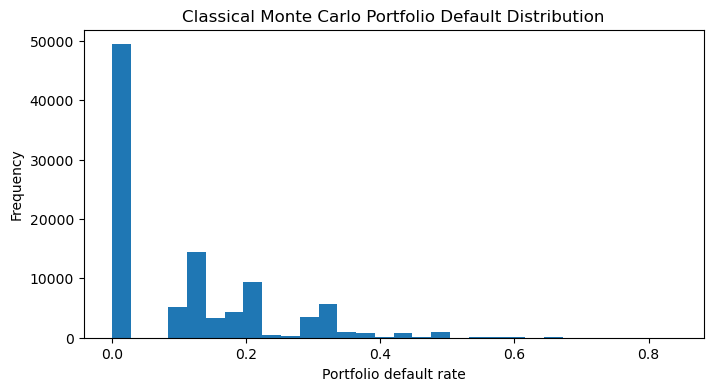

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(default_rates_mc, bins=30)
plt.title("Classical Monte Carlo Portfolio Default Distribution")
plt.xlabel("Portfolio default rate")
plt.ylabel("Frequency")
plt.show()

## 7. Scenario Default Rate (SDR) Output

In [8]:
def scenario_default_rates(default_rates):
    """Return SDR table. SDR is the rating tail quantile times adjustment factor."""
    rows = []
    for rating, target_pd in TRANCHE_TARGET_PD.items():
        raw_quantile = np.quantile(default_rates, 1 - target_pd)
        adjustment = SDR_ADJUSTMENT_FACTOR.get(rating, 1.0)
        rows.append({
            "rating": rating,
            "target_pd": target_pd,
            "raw_default_rate_quantile": raw_quantile,
            "adjustment_factor": adjustment,
            "SDR": raw_quantile * adjustment,
        })
    return pd.DataFrame(rows)

sdr_mc = scenario_default_rates(default_rates_mc)
sdr_mc

,rating,target_pd,raw_default_rate_quantile,adjustment_factor,SDR
0,AAA,0.001,0.60,1.00,0.6000
1,AA,0.005,0.50,1.00,0.5000
2,A,0.030,0.38,1.02,0.3876
3,BBB,0.080,0.32,1.00,0.3200
4,BB,0.200,0.20,1.00,0.2000
5,B,0.350,0.12,1.00,0.1200


# 8. Can Monte Carlo be replaced by quantum techniques?

Conceptually, yes: the relevant quantum technique is usually **Quantum Amplitude Estimation (QAE)**, not quantum simulation of molecules/materials.

QAE can estimate probabilities or expectations with theoretical error scaling roughly `O(1/M)` versus classical Monte Carlo's `O(1/sqrt(M))`, where `M` is the number of oracle calls/samples. But on a normal laptop, a QAE implementation is only a **classical simulation of a quantum circuit**, so it usually does **not** run faster. True speedup requires fault-tolerant quantum hardware and an efficient quantum circuit that prepares the portfolio default distribution.

For this CDO problem, QAE would estimate quantities like:

```text
P(portfolio default rate > threshold)
```

Then an outer search over thresholds can find the SDR.

## 9. Practical comparison: classical MC vs Sobol low-discrepancy simulation

The next method is **not a real quantum computer**. It is a practical Python alternative that often reduces simulation noise: Sobol quasi-Monte Carlo.

I include it because it is executable on a laptop and gives a useful comparison. True QAE is discussed after this section.

In [9]:
def simulate_default_rates_sobol(portfolio, corr, n_power=16, scramble=True, seed=42):
    """Sobol quasi-Monte Carlo version of the same Gaussian-copula simulation.

    n_trials = 2 ** n_power.
    """
    n_assets = len(portfolio)
    chol = np.linalg.cholesky(corr)

    pd_vec = portfolio["pd"].to_numpy()
    par = portfolio["par"].to_numpy()
    total_par = par.sum()
    thresholds = norm.ppf(1 - pd_vec)

    sampler = qmc.Sobol(d=n_assets, scramble=scramble, seed=seed)
    u = sampler.random_base2(m=n_power)

    eps = np.finfo(float).eps
    u = np.clip(u, eps, 1 - eps)

    z = norm.ppf(u)
    x = z @ chol.T

    defaults = x > thresholds
    default_rates = (defaults @ par) / total_par

    return default_rates

start = time.time()
default_rates_sobol = simulate_default_rates_sobol(portfolio, corr, n_power=16, seed=42)
sobol_runtime = time.time() - start

sdr_sobol = scenario_default_rates(default_rates_sobol)

comparison = sdr_mc[["rating", "SDR"]].rename(columns={"SDR": "SDR_classical_MC"}).merge(
    sdr_sobol[["rating", "SDR"]].rename(columns={"SDR": "SDR_sobol_QMC"}),
    on="rating"
)
comparison["difference"] = comparison["SDR_sobol_QMC"] - comparison["SDR_classical_MC"]

print(f"Classical MC trials: {len(default_rates_mc):,}, runtime: {mc_runtime:.4f}s")
print(f"Sobol QMC trials:    {len(default_rates_sobol):,}, runtime: {sobol_runtime:.4f}s")
comparison

Classical MC trials: 100,000, runtime: 0.0156s
Sobol QMC trials:    65,536, runtime: 0.0362s


,rating,SDR_classical_MC,SDR_sobol_QMC,difference
0,AAA,0.6000,0.6000,0.0
1,AA,0.5000,0.5000,0.0
2,A,0.3876,0.3876,0.0
3,BBB,0.3200,0.3200,0.0
4,BB,0.2000,0.2000,0.0
5,B,0.1200,0.1200,0.0


## 10. QAE-ready tail-probability interface

A full QAE implementation needs a quantum circuit that prepares the correlated default distribution and marks scenarios above a threshold. That is nontrivial for this Gaussian copula model.

The function below isolates the target probability that QAE would estimate:

```text
tail_probability(threshold) = P(default_rate > threshold)
```

Classical MC estimates it by counting paths. A real QAE version would replace the counting step with amplitude estimation.

In [10]:
def estimate_tail_probability_classical(default_rates, threshold):
    """Classical estimate of P(default_rate > threshold)."""
    return np.mean(default_rates > threshold)

def find_sdr_by_tail_search(default_rates, target_pd, adjustment_factor=1.0):
    """Find SDR by searching for the smallest threshold whose tail probability is <= target_pd."""
    grid = np.sort(np.unique(default_rates))
    tail_probs = np.array([estimate_tail_probability_classical(default_rates, x) for x in grid])

    valid = np.where(tail_probs <= target_pd)[0]
    threshold = grid[-1] if len(valid) == 0 else grid[valid[0]]
    return threshold * adjustment_factor

rows = []
for rating, target_pd in TRANCHE_TARGET_PD.items():
    rows.append({
        "rating": rating,
        "SDR_quantile_method": float(sdr_mc.loc[sdr_mc.rating == rating, "SDR"].iloc[0]),
        "SDR_tail_search_method": find_sdr_by_tail_search(
            default_rates_mc,
            target_pd,
            SDR_ADJUSTMENT_FACTOR.get(rating, 1.0)
        )
    })

pd.DataFrame(rows)

,rating,SDR_quantile_method,SDR_tail_search_method
0,AAA,0.6000,0.6000
1,AA,0.5000,0.5000
2,A,0.3876,0.3876
3,BBB,0.3200,0.3200
4,BB,0.2000,0.2000
5,B,0.1200,0.1200


## 11. Optional Qiskit placeholder

If you later install Qiskit and Qiskit Finance, the most relevant algorithm family is Quantum Amplitude Estimation. The CDO model would need these quantum pieces:

1. state preparation for correlated default scenarios;
2. comparator/oracle marking `portfolio default rate > threshold`;
3. QAE to estimate the marked probability;
4. bisection over thresholds to find the SDR.

That is possible as a research prototype, but it is not a drop-in replacement for this Gaussian-copula Monte Carlo engine.

In [11]:
try:
    import qiskit
    print("Qiskit is installed:", qiskit.__version__)
    print("Next step: build state-preparation and threshold-oracle circuits for the CDO loss distribution.")
except Exception:
    print("Qiskit is not installed in this environment.")
    print("This notebook still runs the classical MC and Sobol QMC comparison.")

Qiskit is not installed in this environment.
This notebook still runs the classical MC and Sobol QMC comparison.


## Final SDR output

Use `sdr_mc` as the main output table.

In [12]:
sdr_mc

,rating,target_pd,raw_default_rate_quantile,adjustment_factor,SDR
0,AAA,0.001,0.60,1.00,0.6000
1,AA,0.005,0.50,1.00,0.5000
2,A,0.030,0.38,1.02,0.3876
3,BBB,0.080,0.32,1.00,0.3200
4,BB,0.200,0.20,1.00,0.2000
5,B,0.350,0.12,1.00,0.1200
